# Denoising Average

- **Data**:  
  $$
  y_{i,j}, \quad i = 1, \dots, N; \quad j = 1, \dots, M
  $$
  where $y_{i,j}$ is the (power) value of the $j$-th frequency bin in the $i$-th segment's FFT.

- **Goal**:  
  Model the “true” (but unknown) PSD at frequency bin $j$ as some parameter $x_j$ to then obtain a denoised estimate for each bin/frequency.  

- **Assumptions**:
  1. **Approximate stationarity**:  The true PSD does not vary wildly across segments.
  2. **Noticeable peaks**: Some bins may contain larger energy (peaks) consistently across many segments.  
  3. **Unknown noise nature**: We do not assume Gaussian noise.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from src.data_preprocessing import (
    read_oscilloscope_data, 
    segment_signal,
    perform_fft_on_segments,
    plot_random_segments
)

from scipy.signal import resample


In [2]:
# Read real data
df = read_oscilloscope_data(
    file_path='../data/raw/0702 без перекосов фаза A.txt',
    output_path='../data/processed/Anomalous.csv'
    )

noisy_signal = df['Data'].to_numpy()
noisy_signal_mean = np.mean(noisy_signal)
noisy_signal -= noisy_signal_mean

In [3]:
segments = segment_signal(noisy_signal, segment_length=10000, step=20, apply_window=False)

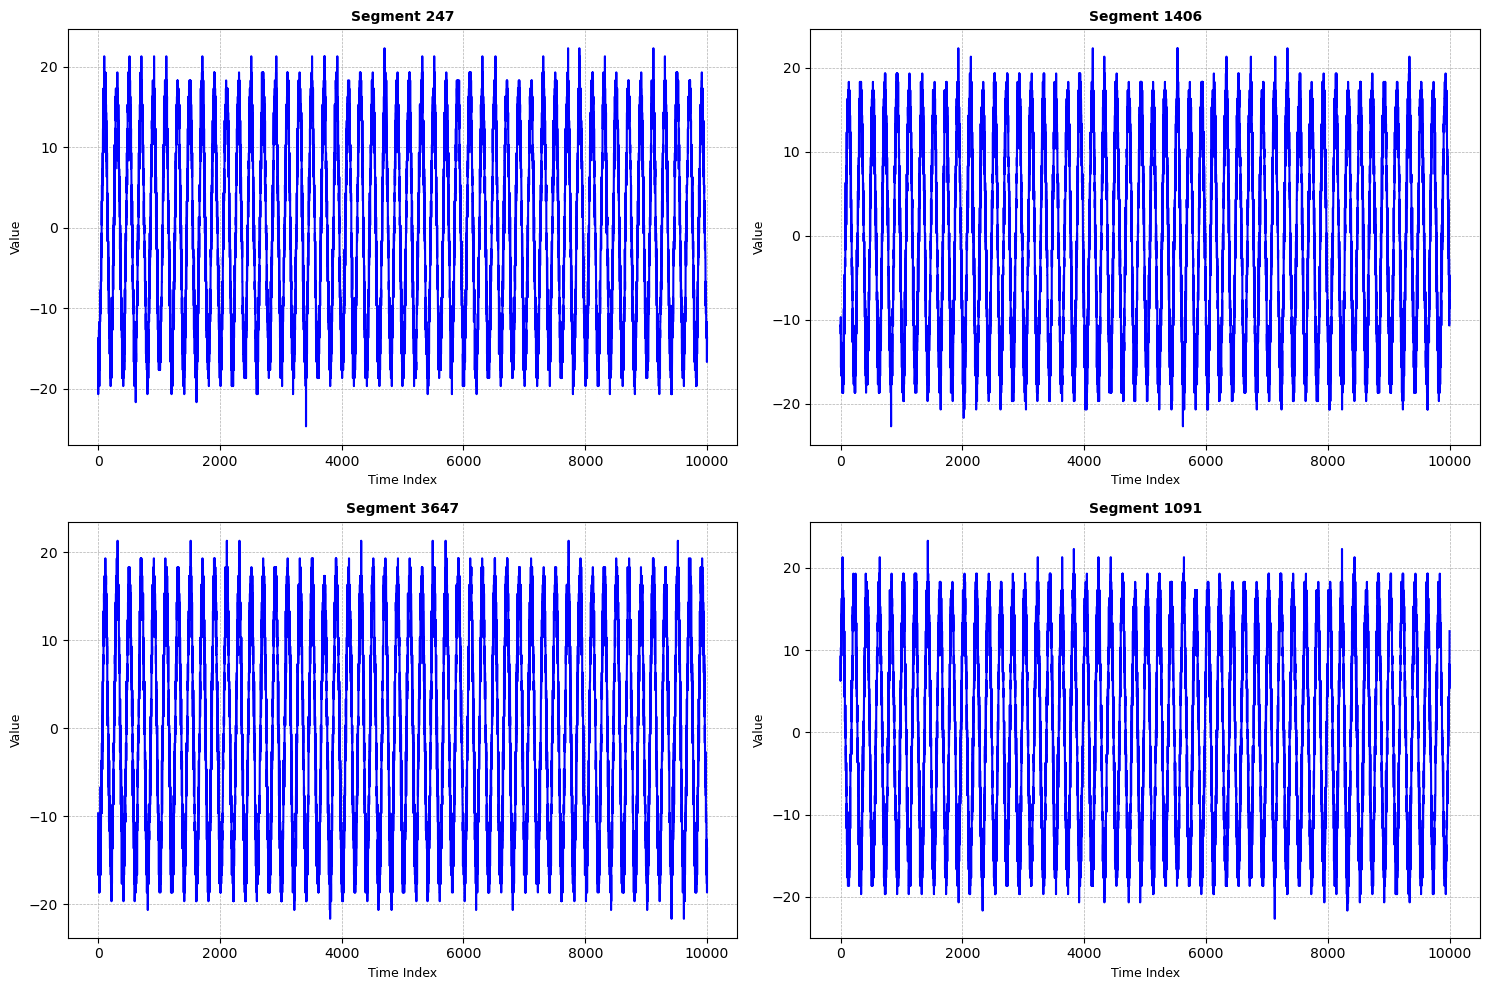

In [4]:
# Plot segments
plot_random_segments(segments, num_segments=4, max_points=None, axis_labels=('Time Index', 'Value'))
plt.show()

In [5]:
fft_segments, freqs = perform_fft_on_segments(segments, f_sampling=10000, db=True, cutoff_freq=250)

## Averaging

In [6]:
def plot_single_segment_with_uncertainty(fft_segments, x_values=None, max_points=1000, n_std=2, title="Spectrum with Uncertainty",
                                         axis_labels=None, highlight_freqs=None, method='closest'):
    """
    Plots the average spectrum with uncertainty boundaries and highlights specific frequencies.

    Parameters:
    - fft_segments: 2D array of FFT segments (rows are segments, columns are data points).
    - x_values: Optional x-axis values corresponding to the spectrum.
    - max_points: Maximum number of points to plot (applies resampling if necessary).
    - n_std: Number of standard deviations for the uncertainty boundary.
    - title: Title for the spectrum.
    - axis_labels: Optional tuple (x_label, y_label) for axis labels.
    - highlight_freqs: List or array of frequencies to highlight on the plot.
    - method: Method to match highlight frequencies ('closest' matches nearest values).
    """
    # Calculate mean and standard deviation
    spectrum_mean = np.mean(fft_segments, axis=0)
    spectrum_std = np.std(fft_segments, axis=0) * n_std  # Scale by number of standard deviations

    # Prepare x-values
    if max_points is not None and len(spectrum_mean) > max_points:
        spectrum_mean = resample(spectrum_mean, max_points)
        spectrum_std = resample(spectrum_std, max_points)
        if x_values is not None:
            if len(x_values.shape) == 1:
                x_values = resample(x_values, max_points)
            else:
                x_values = resample(x_values, max_points)
        else:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))
    else:
        if x_values is None:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))

    # Plot
    x_label, y_label = axis_labels if axis_labels else ('Frequency, Hz', 'Power, dB')
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_values, spectrum_mean, linewidth=2.0, color='blue', label='Mean Spectrum')
    ax.fill_between(
        x_values,
        spectrum_mean - spectrum_std,
        spectrum_mean + spectrum_std,
        color='blue',
        alpha=0.2,
        label=f'Uncertainty (±{n_std} SD)'
    )
    # Add thicker boundary lines for the shaded region
    ax.plot(x_values, spectrum_mean - spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    ax.plot(x_values, spectrum_mean + spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    
    # Highlight specified frequencies
    if highlight_freqs is not None and len(highlight_freqs) > 0:
        for freq in highlight_freqs:
            if method == 'closest':
                # Find the closest frequency in the x_values
                closest_idx = np.abs(x_values - freq).argmin()
                ax.scatter(x_values[closest_idx], spectrum_mean[closest_idx], color='red', s=50)
    
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel(y_label, fontsize=9)
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    return fig, ax

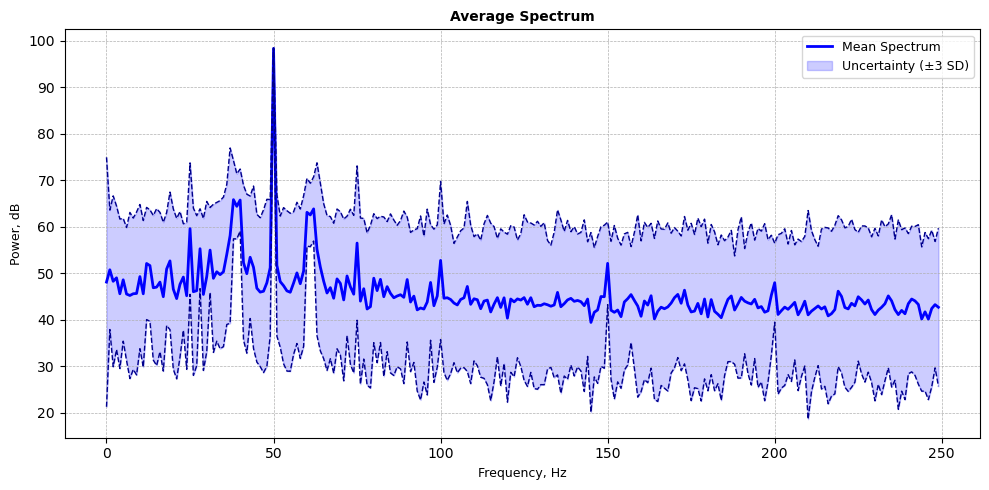

In [7]:
plot_single_segment_with_uncertainty(fft_segments, x_values=freqs, n_std=3, title='Average Spectrum')
plt.show()

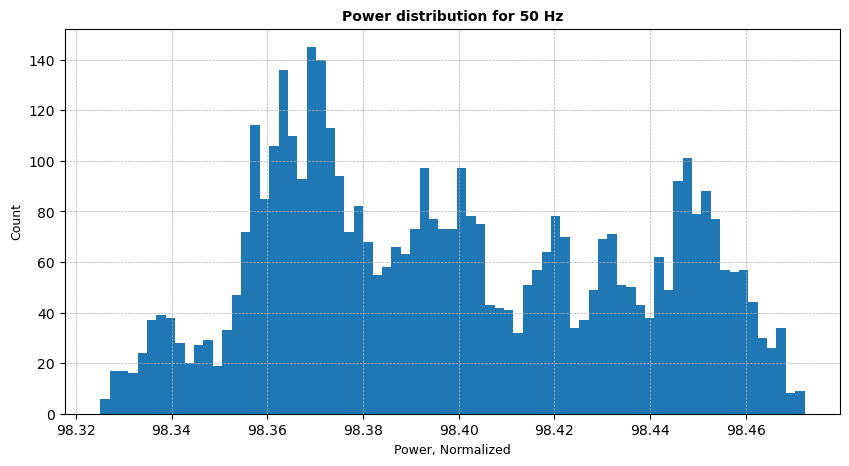

In [8]:
freq2dist = 50

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(fft_segments[:, freq2dist], bins=75)
ax.set_xlabel('Power, Normalized', fontsize=9)
ax.set_ylabel('Count', fontsize=9)
ax.set_title(f'Power distribution for {freq2dist} Hz', fontsize=10, fontweight='bold')
ax.grid(True, linestyle='--', linewidth=0.5)
plt.show()

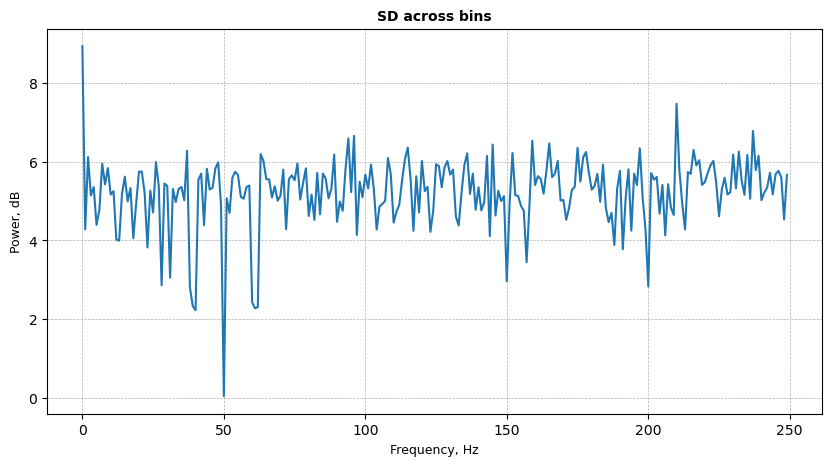

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(np.std(fft_segments, axis=0))
ax.set_xlabel('Frequency, Hz', fontsize=9)
ax.set_ylabel('Power, dB', fontsize=9)
ax.set_title('SD across bins', fontsize=10, fontweight='bold')
ax.grid(True, linestyle='--', linewidth=0.5)
plt.show()

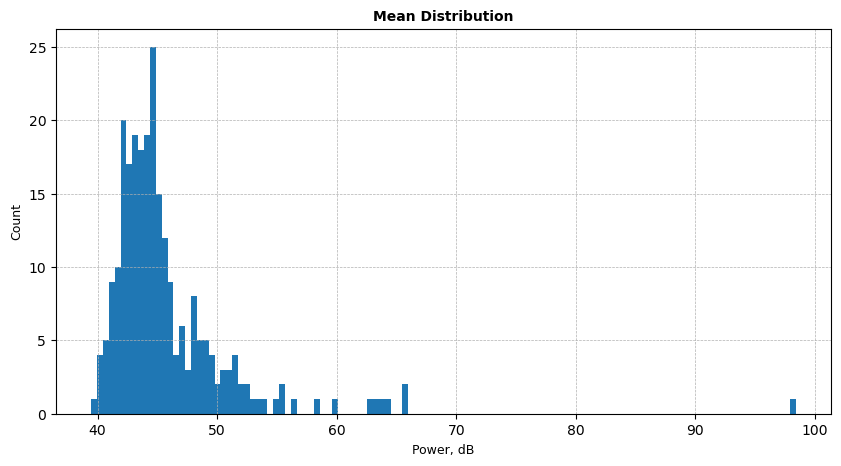

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.mean(fft_segments, axis=0), bins=120)
ax.set_xlabel('Power, dB', fontsize=9)
ax.set_ylabel('Count', fontsize=9)
ax.set_title('Mean Distribution', fontsize=10, fontweight='bold')
ax.grid(True, linestyle='--', linewidth=0.5)
plt.show()


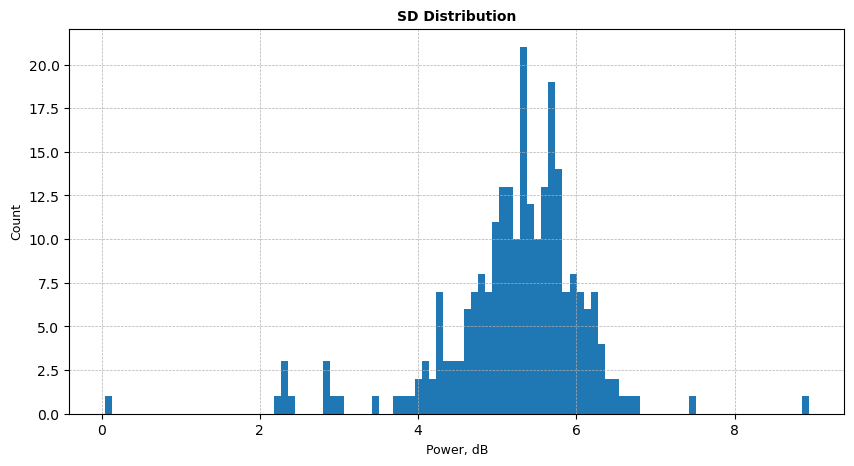

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.std(fft_segments, axis=0), bins=100)
ax.set_xlabel('Power, dB', fontsize=9)
ax.set_ylabel('Count', fontsize=9)
ax.set_title('SD Distribution', fontsize=10, fontweight='bold')
ax.grid(True, linestyle='--', linewidth=0.5)
plt.show()

In [12]:
print(f'Average standard deviation across bins: {np.round(np.mean(np.std(fft_segments, axis=0)), 3)} dB')

Average standard deviation across bins: 5.225 dB
